In [1]:
source("../R/shared_data.R")
data_features_core <- load_analysis_data()
var_quanti <- names(data_features_core)[sapply(data_features_core, is.numeric)]

library(FactoMineR)
library(factoextra)

# ACP centrée-réduite (scale.unit = TRUE par défaut)
acp <- PCA(data_features_core %>% select(all_of(var_quanti)) %>%
             select(-c("log_candidats", "log_admis","log_capacite")),,
           scale.unit = TRUE,
           graph = FALSE)

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



In [2]:
glimpse(data_features_core)

Rows: 14,252
Columns: 31
$ Établissement                                                                          <fct> …
$ Statut.Etablissement                                                                   <fct> …
$ Filière.de.formation                                                                   <fct> …
$ Filière.de.formation.très.agrégée                                                      <fct> …
$ Région.de.l.établissement                                                              <fct> …
$ Académie.de.l.établissement                                                            <fct> …
$ Sélectivité                                                                            <fct> …
$ Capacité.de.l.établissement.par.formation                                              <dbl> …
$ Effectif.total.admis.2phases                                                           <dbl> …
$ Effectif.total.candidats.2phases                                                       <dbl> …
$ Pou

In [3]:
summary(select(data_features_core, Filière.de.formation.très.agrégée))
levels(data_features_core$Filière.de.formation.très.agrégée)

 Filière.de.formation.très.agrégée
 BTS              :5351           
 Licence          :3052           
 Autre formation  :1815           
 CPGE             : 986           
 BUT              : 820           
 Ecole d'Ingénieur: 585           
 (Other)          :1643           

[1] "Autre formation"   "BTS"               "BUT"              
 [4] "CPGE"              "Ecole d'Ingénieur" "Ecole de Commerce"
 [7] "EFTS"              "IFSI"              "Licence"          
[10] "Licence_Las"       "PASS"

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


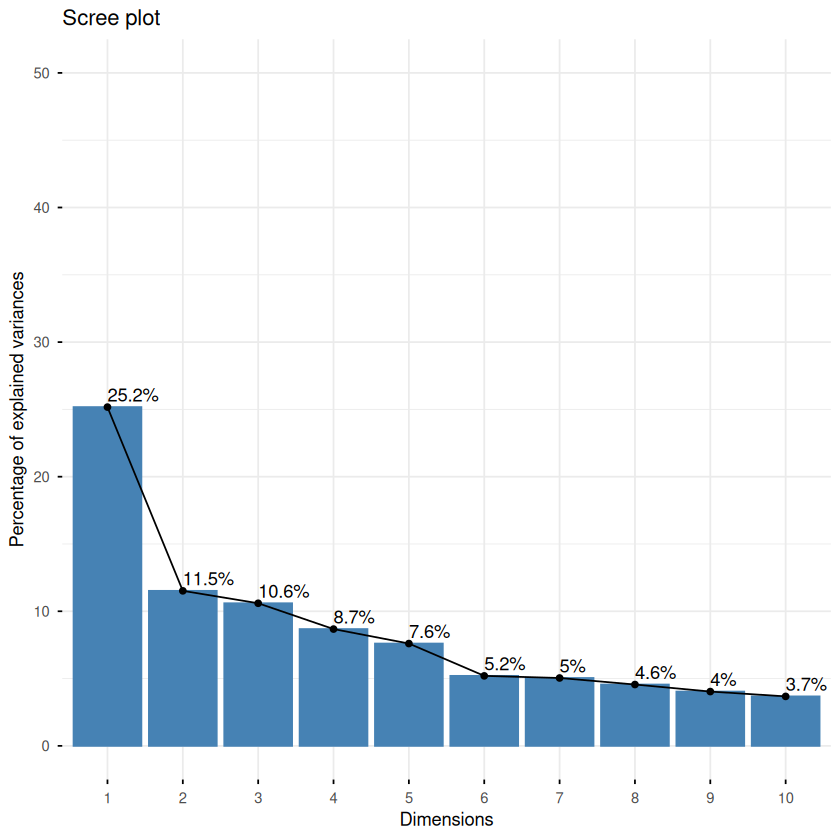

In [4]:
# Variance expliquée par axe
fviz_eig(acp, addlabels = TRUE, ylim = c(0, 50))

In [5]:
library(knitr)

contrib_var <- as.data.frame(acp$var$contrib)
kable(round(contrib_var, 2), caption = "Contributions des variables aux axes factoriels (%)")



Table: Contributions des variables aux axes factoriels (%)

|                                                                                       | Dim.1| Dim.2| Dim.3| Dim.4| Dim.5|
|:--------------------------------------------------------------------------------------|-----:|-----:|-----:|-----:|-----:|
|Capacité.de.l.établissement.par.formation                                              |  0.72| 15.28|  5.37| 11.63|  2.09|
|Effectif.total.admis.2phases                                                           |  1.46| 18.46|  3.75| 14.06|  1.18|
|Effectif.total.candidats.2phases                                                       |  5.45|  8.18|  0.79|  9.50|  2.67|
|Pourcentage.boursiers.candidats                                                        |  3.80|  2.18| 16.41|  1.05|  4.02|
|Pourcentage.boursiers.admis                                                            |  2.97|  1.55| 12.43|  1.41|  4.48|
|pct_filles_admises                                            

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>.”


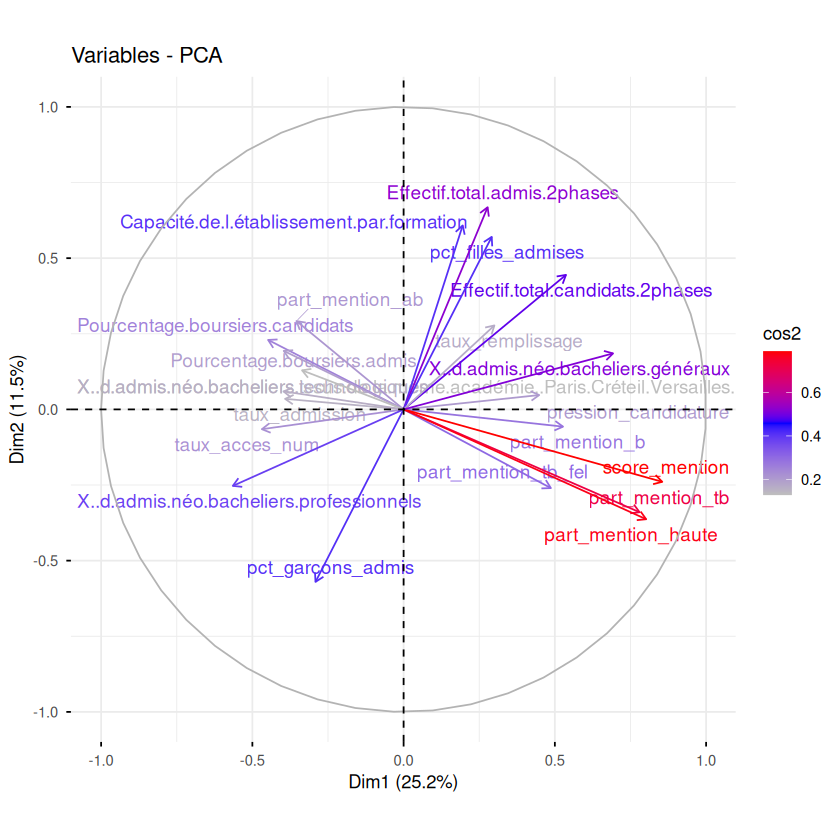

In [6]:
# Cercle des corrélations (variables)
fviz_pca_var(acp,
             col.var = "cos2",        # colorier selon qualité de représentation
             gradient.cols = c("grey", "blue", "red"),
             repel = TRUE)            # éviter le chevauchement des labels


Interprétation : La première dim semble représenter les fillières très sélectives, adressées aux bacs généraux, avec un faible taux d'admission et avec des candidats ayant reçu une bonne mention au bac.

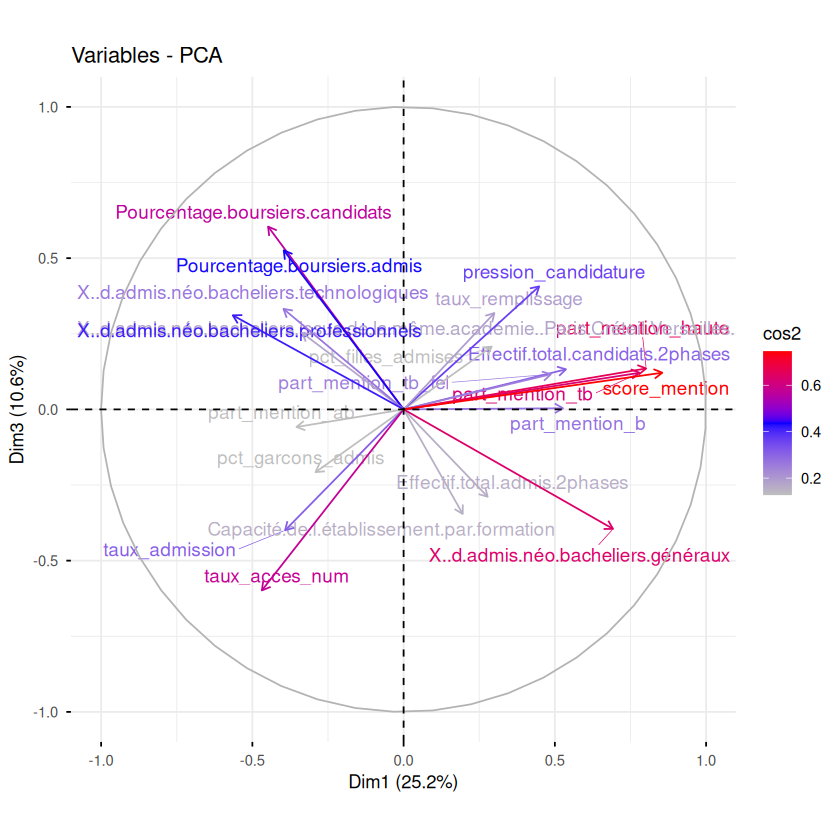

In [7]:
#projection des variables selon les axes 1 et 3

fviz_pca_var(acp, axes = c(1, 3), 
             col.var = "cos2",        # colorier selon qualité de représentation
             gradient.cols = c("grey", "blue", "red"),
             repel = TRUE)

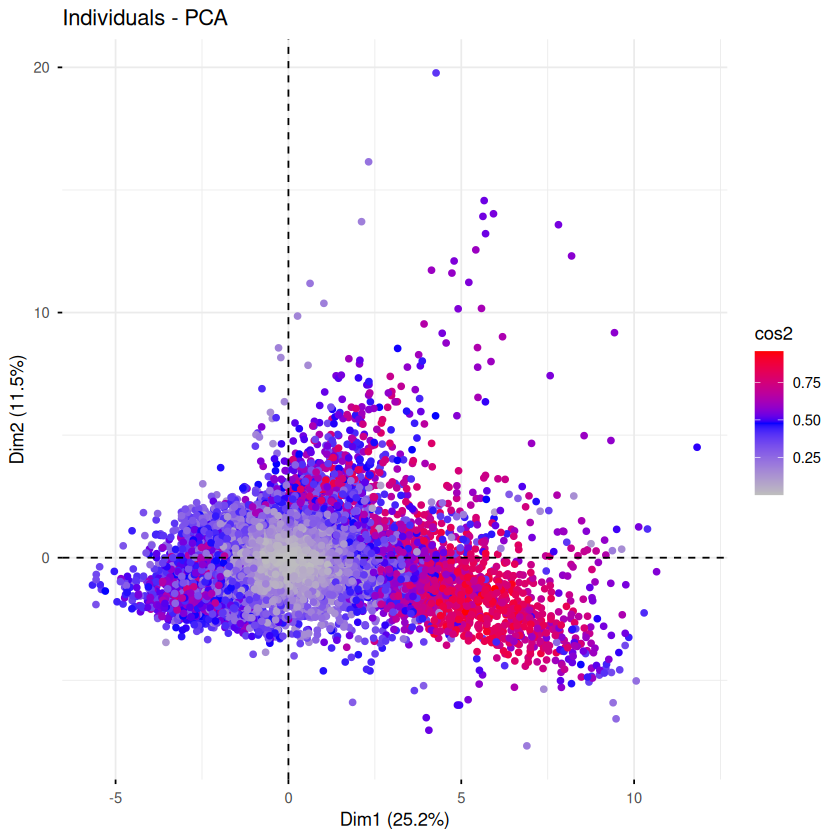

In [8]:
# Projection des individus
fviz_pca_ind(acp,
             col.ind = "cos2",
             gradient.cols = c("grey", "blue", "red"),
             repel = FALSE,
             label="none")

Test de visualisation des individus dans différents axes selon plusieurs variables.

Ignoring unknown labels:
• fill : "Sélectivité"
• linetype : "Sélectivité"


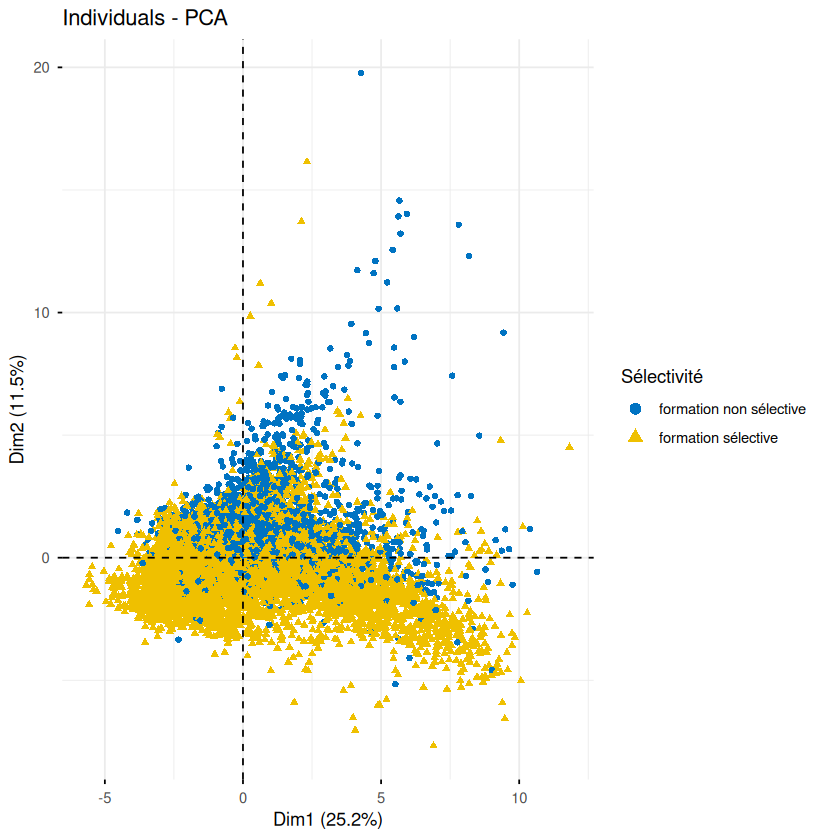

In [9]:
fviz_pca_ind(acp,
             col.ind = data_features_core$Sélectivité,  # variable quali
             palette = "jco",          # palette de couleurs
             addEllipses = FALSE,       # ellipses de confiance par groupe
             legend.title = "Sélectivité",
             label = "none")

Axe 2 semble séparer formations sélectives des non-sélectives

Ignoring unknown labels:
• fill : "Statut de l'établissement"
• linetype : "Statut de l'établissement"


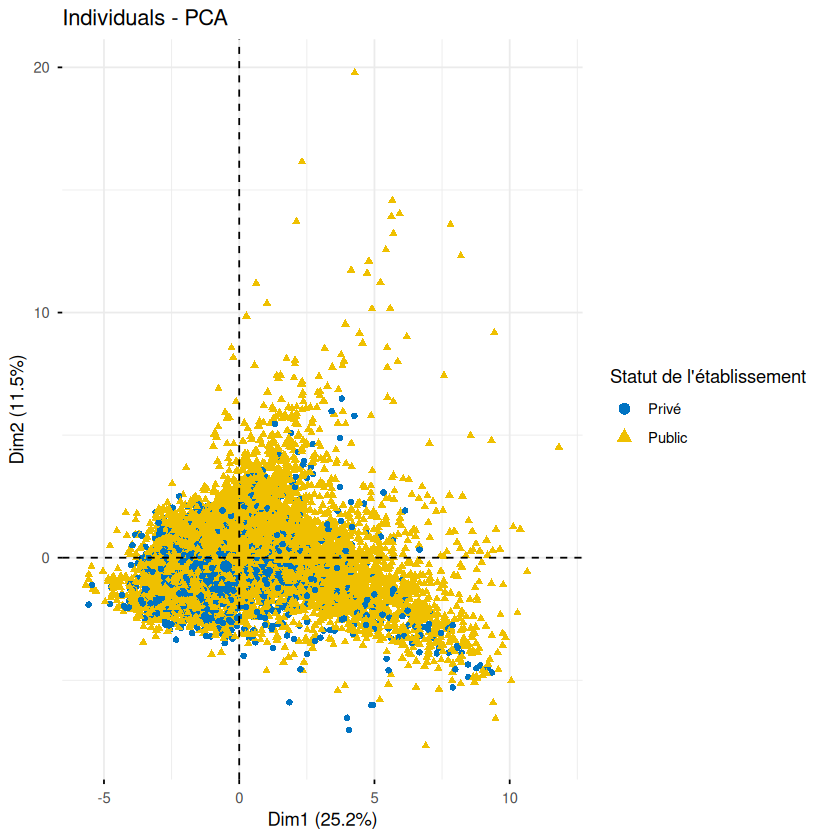

In [10]:
fviz_pca_ind(acp,
             col.ind = data_features_core$Statut.Etablissement,  # variable quali
             palette = "jco",          # palette de couleurs
             addEllipses = FALSE,       # ellipses de confiance par groupe
             legend.title = "Statut de l'établissement",
             label = "none")

Ignoring unknown labels:
• fill : "Nombre de candidats (log)"
• linetype : "Nombre de candidats (log)"
• shape : "Nombre de candidats (log)"


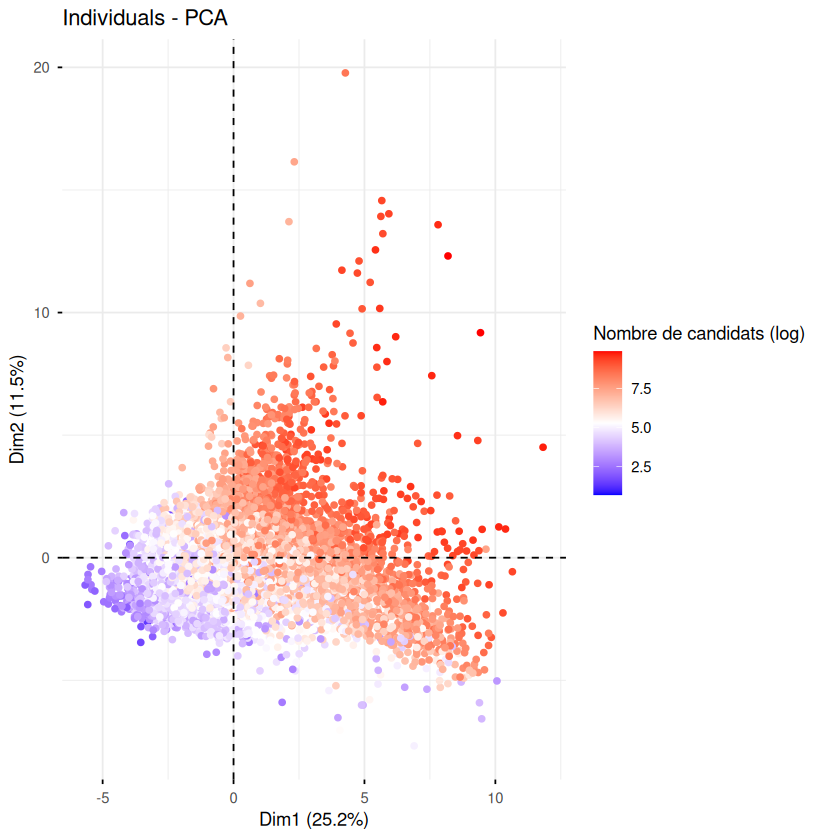

In [11]:
fviz_pca_ind(acp,
             col.ind = data_features_core$log_candidats,  # variable quanti
             gradient.cols = c("blue", "white", "red"),
             legend.title = "Nombre de candidats (log)",
             label = "none")

L'axe 1 semble séparer les gros établissements des petits.

Ignoring unknown labels:
• fill : "Part de mentions TB et plus"
• linetype : "Part de mentions TB et plus"
• shape : "Part de mentions TB et plus"


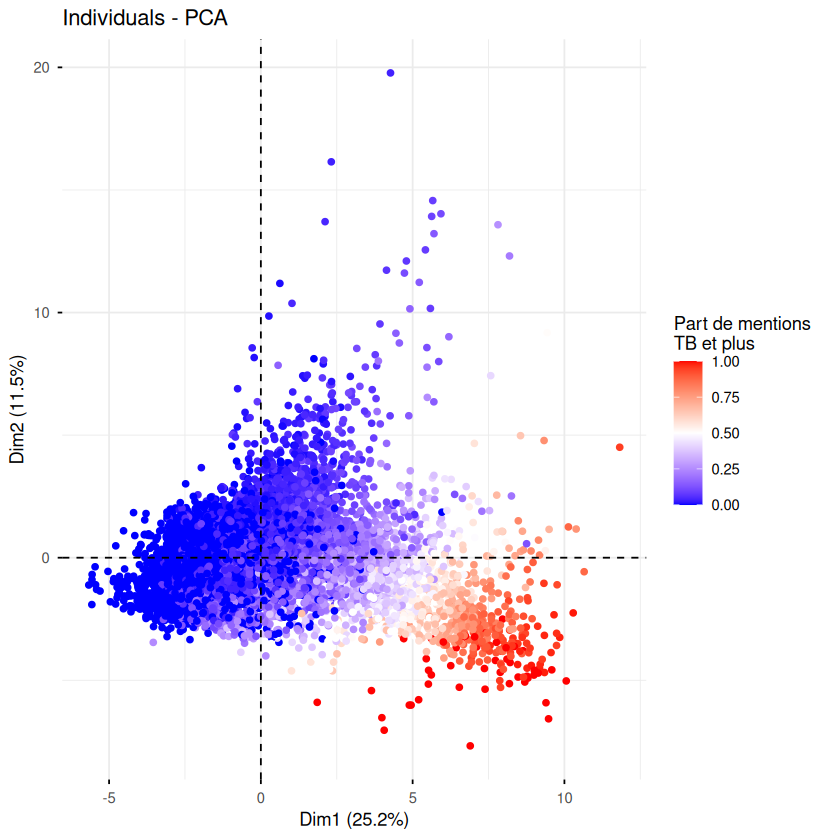

In [12]:
fviz_pca_ind(acp,
             col.ind = data_features_core$part_mention_haute,  # variable quanti
             gradient.cols = c("blue", "white", "red"),
             legend.title = "Part de mentions\nTB et plus",
             label = "none")

Ignoring unknown labels:
• fill : "Part de bacs généraux"
• linetype : "Part de bacs généraux"
• shape : "Part de bacs généraux"


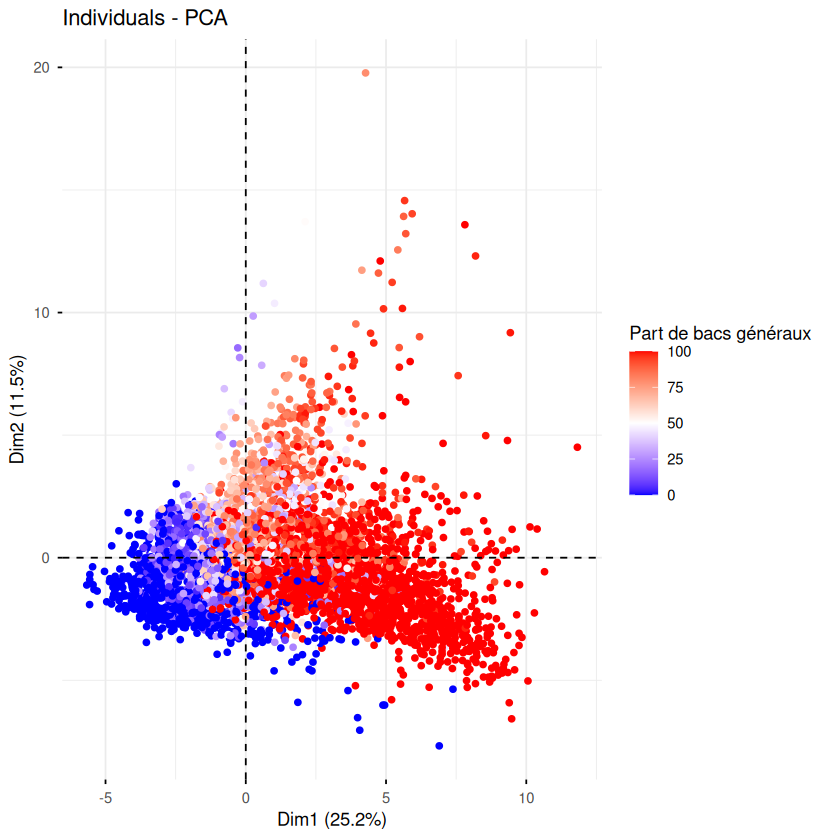

In [13]:
fviz_pca_ind(acp,
             col.ind = data_features_core$X..d.admis.néo.bacheliers.généraux,  # variable quanti
             gradient.cols = c("blue", "white", "red"),
             legend.title = "Part de bacs généraux",
             label = "none")

Pour plus de visibilité, on peut choisir de représenter uniquement certaines filières les unes après les autres.

In [22]:
summary(data_features_core$Filière.de.formation.très.agrégée)

Autre formation               BTS               BUT              CPGE 
             1815              5351               820               986 
Ecole d'Ingénieur Ecole de Commerce              EFTS              IFSI 
              585               256               243               344 
          Licence       Licence_Las              PASS 
             3052               513               287

Ignoring unknown labels:
• fill : "Filière de formation"
• linetype : "Filière de formation"


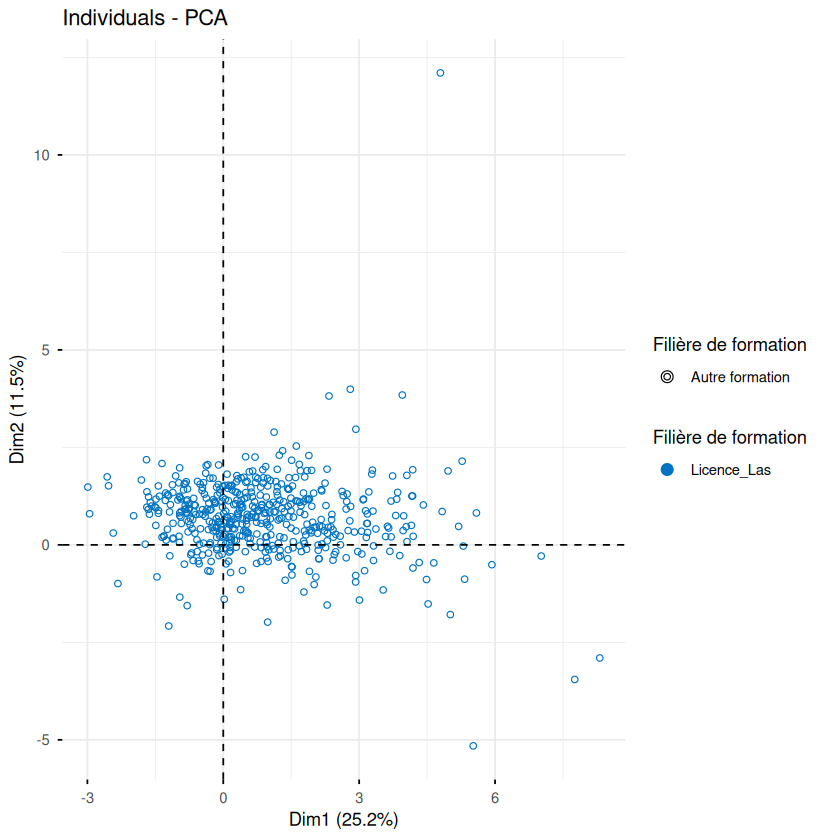

In [27]:
fviz_pca_ind(acp,
             col.ind = data_features_core$Filière.de.formation.très.agrégée, 
             select.ind = list(
               name = which(
                 data_features_core$Filière.de.formation.très.agrégée %in% c("Licence_Las")
               )
             ),
             palette = "jco",
             legend.title = "Filière de formation",
             label = "none")

Ignoring unknown labels:
• fill : "Types d'établissements"
• linetype : "Types d'établissements"
Warning message:
“This manual palette can handle a maximum of 10 values. You have supplied 11”
Warning message:
“Removed 287 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


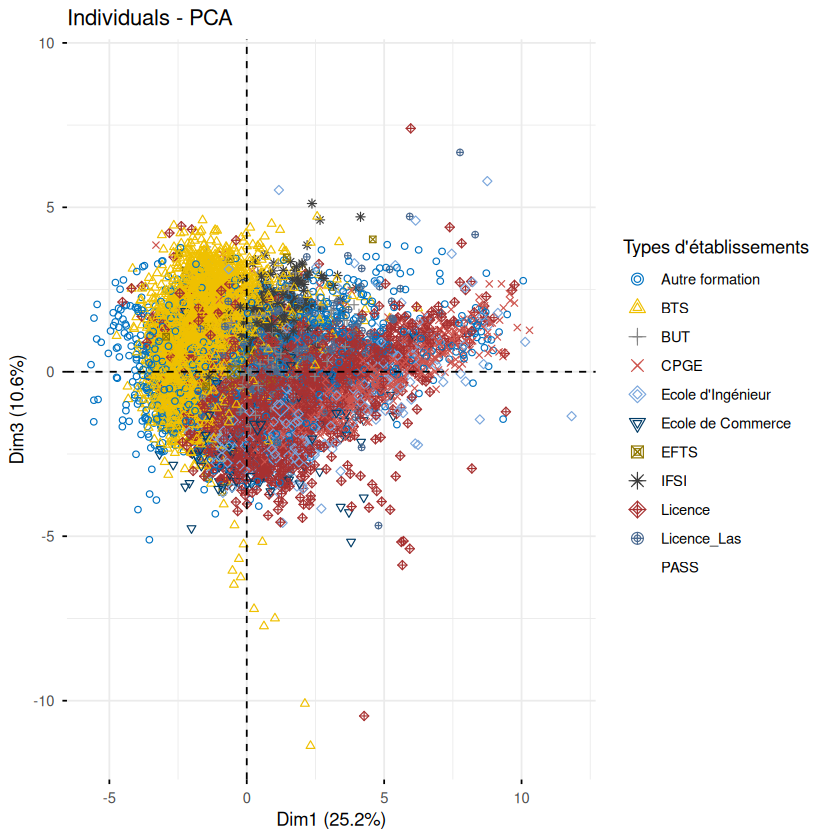

In [15]:
fviz_pca_ind(acp,
            axes = c(1, 3),
             col.ind = data_features_core$Filière.de.formation.très.agrégée,  # variable quanti
             palette = "jco",
             legend.title = "Types d'établissements",
             label = "none")